In [1]:
import obspy
import resampy
import soundfile as sf
import numpy as np
import matplotlib.pyplot as plt

# Konfiguration
x = 10  # Anzahl Samples, die als Ränder verwendet werden
target_rate = 44100  # Ziel-Abtastrate in Hz

# Datei-Pfade
mseed_files = [
    #"block_0000_20250519_155827.mseed",  # Block 1
   # "block_0001_20250519_155852.mseed",  # Block 2
   # "block_0002_20250519_155919.mseed"   # Block 3
    "block_0313_SALP_20250618_140554_40_372.mseed"
    "block_0314_SALP_20250618_140603_40_365.mseed"
    "block_0315_SALP_20250618_140608_40_210.mseed"
]

# Schritt 1: Rohdaten vorbereiten
trace1 = obspy.read(mseed_files[0])[0]
trace2 = obspy.read(mseed_files[1])[0]
trace3 = obspy.read(mseed_files[2])[0]

sr_original = trace1.stats.sampling_rate

print("📥 Originaldaten:")
print(f"  Block 1: {len(trace1.data)} Samples ({len(trace1.data)/sr_original:.2f} s)")
print(f"  Block 2: {len(trace2.data)} Samples ({len(trace2.data)/sr_original:.2f} s)")
print(f"  Block 3: {len(trace3.data)} Samples ({len(trace3.data)/sr_original:.2f} s)")

# Schritt 2: Ränder anhängen
segment1 = trace1.data[-x:].astype(np.float32)
segment2 = trace2.data.astype(np.float32)
segment3 = trace3.data[:x].astype(np.float32)

combined = np.concatenate([segment1, segment2, segment3])
print(f"\n🔗 Zusammengesetztes Signal (vor Resampling):")
print(f"  Samples: {len(combined)}")
print(f"  Dauer: {len(combined)/sr_original:.2f} s")

# Schritt 3: Resample
resampled = resampy.resample(combined, sr_orig=sr_original, sr_new=target_rate)
print(f"\n🎚️  Resampling auf {target_rate} Hz:")
print(f"  Samples: {len(resampled)}")
print(f"  Dauer: {len(resampled)/target_rate:.2f} s")

# Schritt 4: Ränder wieder entfernen (entsprechend x bei neuer Samplerate)
x_new = int((x / sr_original) * target_rate)
trimmed = resampled[x_new:-x_new]
print(f"\n✂️  Beschnittenes Signal (nach Resampling):")
print(f"  Entfernte Ränder: {x_new} Samples vorn und hinten")
print(f"  Verbleibende Samples: {len(trimmed)}")
print(f"  Dauer: {len(trimmed)/target_rate:.2f} s")

# Schritt 5: Normalisieren & speichern
trimmed /= np.max(np.abs(trimmed))
sf.write("final_trimmed.wav", trimmed, samplerate=target_rate)
print("\n💾 WAV gespeichert als: final_trimmed.wav")


FileNotFoundError: [Errno 2] No such file or directory: 'block_0313_SALP_20250618_140554_40_372.mseedblock_0314_SALP_20250618_140603_40_365.mseedblock_0315_SALP_20250618_140608_40_210.mseed'

In [ ]:
time_axis = np.linspace(0, len(trimmed)/target_rate, num=len(trimmed))

plt.figure(figsize=(12, 4))
plt.plot(time_axis, trimmed)
plt.title("Finale Wellenform (mit Rändern entfernt)")
plt.xlabel("Zeit [s]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()


In [38]:
import obspy
import resampy
import soundfile as sf
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter

# Hochpassfilter-Funktion
def highpass_filter(data, cutoff_hz, sample_rate, order=4):
    nyquist = 0.5 * sample_rate
    norm_cutoff = cutoff_hz / nyquist
    b, a = butter(order, norm_cutoff, btype='high', analog=False)
    return lfilter(b, a, data)

# Konfiguration
x = 10  # Samples von Randblöcken
cutoff_freq = 1  # Hochpassfilter bei 300 Hz
target_rate = 44100

# MSEED-Dateien
mseed_files = [
    "block_0000_20250519_155827.mseed",  # Block 1
    "block_0001_20250519_155852.mseed",  # Block 2
    "block_0002_20250519_155919.mseed"   # Block 3
]

# Traces laden
trace1 = obspy.read(mseed_files[0])[0]
trace2 = obspy.read(mseed_files[1])[0]
trace3 = obspy.read(mseed_files[2])[0]
sr_original = trace1.stats.sampling_rate

print("📥 Originaldaten:")
print(f"  Block 1: {len(trace1.data)} Samples ({len(trace1.data)/sr_original:.2f} s)")
print(f"  Block 2: {len(trace2.data)} Samples ({len(trace2.data)/sr_original:.2f} s)")
print(f"  Block 3: {len(trace3.data)} Samples ({len(trace3.data)/sr_original:.2f} s)")

# Ränder vorbereiten
segment1 = trace1.data[-x:].astype(np.float32)
segment2 = trace2.data.astype(np.float32)
segment3 = trace3.data[:x].astype(np.float32)
combined = np.concatenate([segment1, segment2, segment3])

print(f"\n🔗 Kombiniert (vor Resampling): {len(combined)} Samples ({len(combined)/sr_original:.2f} s)")

# Resampling
resampled = resampy.resample(combined, sr_orig=sr_original, sr_new=target_rate)
print(f"🎚️  Resampled: {len(resampled)} Samples ({len(resampled)/target_rate:.2f} s)")

# Hochpassfilter
filtered = highpass_filter(resampled, cutoff_hz=cutoff_freq, sample_rate=target_rate)
print(f"🔊 Hochpassfilter angewendet bei {cutoff_freq} Hz")

# Abschneiden nach Filter
x_new = int((x / sr_original) * target_rate)
if len(filtered) <= 2 * x_new:
    raise ValueError(f"❌ Zu kurz zum Abschneiden: {len(filtered)} Samples, x_neu = {x_new}")

trimmed = filtered[x_new:-x_new]
print(f"✂️  Beschnitten: {len(trimmed)} Samples ({len(trimmed)/target_rate:.2f} s)")

# Normalisieren & speichern
trimmed /= np.max(np.abs(trimmed))
sf.write("final_filtered.wav", trimmed, samplerate=target_rate)
print("\n💾 WAV gespeichert als: final_filtered.wav")


📥 Originaldaten:
  Block 1: 529 Samples (26.45 s)
  Block 2: 514 Samples (25.70 s)
  Block 3: 532 Samples (26.60 s)

🔗 Kombiniert (vor Resampling): 534 Samples (26.70 s)
🎚️  Resampled: 1177470 Samples (26.70 s)
🔊 Hochpassfilter angewendet bei 1 Hz
✂️  Beschnitten: 1133370 Samples (25.70 s)

💾 WAV gespeichert als: final_filtered.wav


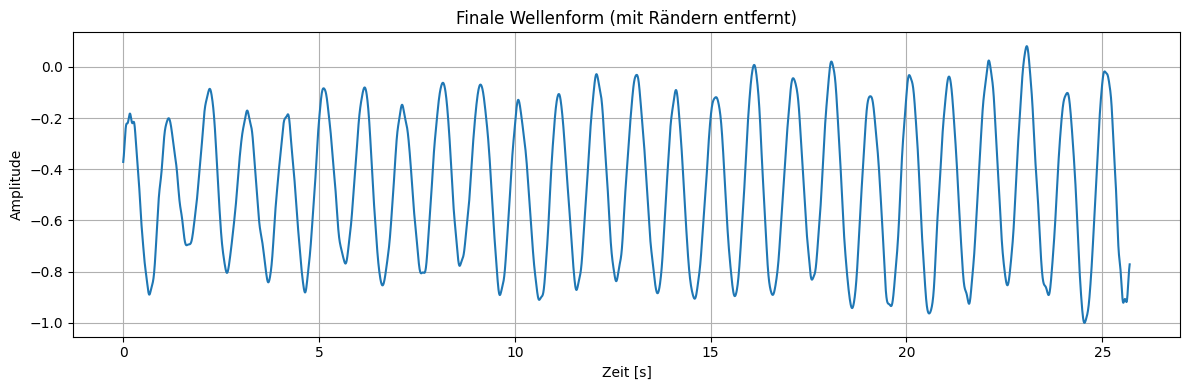

In [39]:
time_axis = np.linspace(0, len(trimmed)/target_rate, num=len(trimmed))

plt.figure(figsize=(12, 4))
plt.plot(time_axis, trimmed)
plt.title("Finale Wellenform (mit Rändern entfernt)")
plt.xlabel("Zeit [s]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()

In [42]:
import soxr
print(dir(soxr))



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/enduser/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/enduser/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/Users/enduser/anaconda3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.start()
  File "/Users

ImportError: numpy.core.multiarray failed to import (auto-generated because you didn't call 'numpy.import_array()' after cimporting numpy; use '<void>numpy._import_array' to disable if you are certain you don't need it).